## 1. Učitavanje i analiza podataka

Učitavanje neophodnih biblioteka

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, precision_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.metrics import f1_score, roc_auc_score
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import pearsonr 

Učitavanje dataseta

In [3]:
df=pd.read_csv('airline_passenger_satisfaction.csv')

prikaz informacija o datasetu i prvih 5 kolona iz dataseta

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      125000 non-null  int64  
 1   Gender                                  125000 non-null  object 
 2   Age                                     125000 non-null  int64  
 3   Customer Type                           125000 non-null  object 
 4   Type of Travel                          125000 non-null  object 
 5   Class                                   125000 non-null  object 
 6   Flight Distance                         125000 non-null  int64  
 7   Departure Delay                         125000 non-null  int64  
 8   Arrival Delay                           124624 non-null  float64
 9   Departure and Arrival Time Convenience  125000 non-null  int64  
 10  Ease of Online Booking                  1250

In [5]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


Prikaz broja null vrijednosti za svaku varijablu

In [6]:
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             376
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

Uklanjanje varijabli koje se neće razmatrati dalje

In [7]:
df.drop(['ID', 'Ease of Online Booking'], axis=1, inplace=True)

Procenat nedostajućih vrijednosti

In [8]:
missing = df.isnull().sum().sum()

missing_percentage = (missing / len(df)) * 100

print(missing_percentage)

0.30079999999999996


Računanje zakrivljenosti i zaobljenosti za varijablu Arrival Delay

In [9]:
df['Arrival Delay'].skew()

np.float64(6.666252142496084)

In [10]:
df['Arrival Delay'].kurt()

np.float64(94.94688995723821)

Analiza variranja varijabli

In [11]:
# Za numeričke varijable
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Kreiranje tabele sa mjerama variranja
variance_table = pd.DataFrame()

for col in numeric_cols:
    data = df[col].dropna()
    
    variance_table.loc[col, 'Raspon (Range)'] = data.max() - data.min()
    variance_table.loc[col, 'Interkvartilni raspon (IQR)'] = data.quantile(0.75) - data.quantile(0.25)
    variance_table.loc[col, 'Varijansa'] = data.var()
    variance_table.loc[col, 'Standardna devijacija'] = data.std()
    variance_table.loc[col, 'Koeficijent varijacije (CV)'] = data.std() / data.mean() if data.mean() != 0 else np.nan
    variance_table.loc[col, 'Mean'] = data.mean()
    variance_table.loc[col, 'Median'] = data.median()

print("MJERE VARIJANJA ZA NUMERIČKE VARIJABLE:")
print(variance_table.round(2))

MJERE VARIJANJA ZA NUMERIČKE VARIJABLE:
                                        Raspon (Range)  \
Age                                               78.0   
Flight Distance                                 4952.0   
Departure Delay                                 1592.0   
Arrival Delay                                   1584.0   
Departure and Arrival Time Convenience             5.0   
Check-in Service                                   5.0   
Online Boarding                                    5.0   
Gate Location                                      5.0   
On-board Service                                   5.0   
Seat Comfort                                       5.0   
Leg Room Service                                   5.0   
Cleanliness                                        5.0   
Food and Drink                                     5.0   
In-flight Service                                  5.0   
In-flight Wifi Service                             5.0   
In-flight Entertainment         

Popunjavanje nedostajućih vrijednosti za varijablu Arrival Delay

In [12]:
df['Arrival Delay'] = df['Arrival Delay'].fillna(df['Arrival Delay'].median())

Deskriptivna statistika

In [13]:
df.describe()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000,125000.000000
mean,39.420872,1180.574136,14.932680,15.243184,3.059968,3.303288,3.249728,2.977056,3.381016,3.440104,3.348808,3.286552,3.205496,3.639752,2.730160,3.359088,3.628920
std,15.113109,996.742849,38.411705,38.751352,1.527038,1.267712,1.351439,1.278636,1.287901,1.319452,1.317283,1.314329,1.330522,1.177910,1.330161,1.334172,1.181883
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,27.000000,409.000000,0.000000,0.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,40.000000,834.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,51.000000,1723.000000,13.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Računanje iskrivljenosti za numeričke varijable 

In [14]:
numeric_cols = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 
                'Departure and Arrival Time Convenience', 'Check-in Service', 
                'Online Boarding', 'Gate Location', 'On-board Service', 
                'Seat Comfort', 'Leg Room Service', 'Cleanliness', 
                'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 
                'In-flight Entertainment', 'Baggage Handling']

# Izračunavanje skewness sa opisom
skewness_results = []

for col in numeric_cols:
    if col in df.columns:
        data = df[col].dropna()
        skew_val = data.skew()
        
        # Tumačenje vrijednosti
        if skew_val > 1:
            interpretation = "JAKO pozitivna (dugi desni rep)"
        elif skew_val > 0.5:
            interpretation = "Umjereno pozitivna"
        elif skew_val > -0.5:
            interpretation = "Približno simetrična"
        elif skew_val > -1:
            interpretation = "Umjereno negativna"
        else:
            interpretation = "JAKO negativna (dugi lijevi rep)"
        
        skewness_results.append({
            'Varijabla': col,
            'Skewness': skew_val,
            'Interpretacija': interpretation
        })

# Kreiranje tabele
skewness_df = pd.DataFrame(skewness_results)
skewness_df = skewness_df.sort_values('Skewness', ascending=False)

print(skewness_df.to_string(index=False))

                             Varijabla  Skewness                  Interpretacija
                       Departure Delay  6.818114 JAKO pozitivna (dugi desni rep)
                         Arrival Delay  6.675002 JAKO pozitivna (dugi desni rep)
                       Flight Distance  1.132893 JAKO pozitivna (dugi desni rep)
                In-flight Wifi Service  0.037776            Približno simetrična
                                   Age -0.001167            Približno simetrična
                         Gate Location -0.057917            Približno simetrična
                        Food and Drink -0.156515            Približno simetrična
                           Cleanliness -0.301059            Približno simetrična
Departure and Arrival Time Convenience -0.334378            Približno simetrična
                      Leg Room Service -0.348008            Približno simetrična
                      Check-in Service -0.363089            Približno simetrična
               In-flight Ent

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  125000 non-null  object 
 1   Age                                     125000 non-null  int64  
 2   Customer Type                           125000 non-null  object 
 3   Type of Travel                          125000 non-null  object 
 4   Class                                   125000 non-null  object 
 5   Flight Distance                         125000 non-null  int64  
 6   Departure Delay                         125000 non-null  int64  
 7   Arrival Delay                           125000 non-null  float64
 8   Departure and Arrival Time Convenience  125000 non-null  int64  
 9   Check-in Service                        125000 non-null  int64  
 10  Online Boarding                         1250

Konverzija kategoričkih varijabli u numeričke

In [16]:
categorical_var = ['Customer Type', 'Type of Travel', 'Class', 'Satisfaction']

for var in categorical_var:
    if var in df.columns:
        unique_values = df[var].unique()
        value_counts = df[var].value_counts()
        
        print(f"\n{var}:")
        print(f"   Broj unikatnih vrijednosti: {len(unique_values)}")
        print(f"   Unikatne vrijednosti: {list(unique_values)}")
        print(f"\n   Frekvencije:")
        for value in unique_values:
            count = value_counts[value]
            percentage = (count / len(df)) * 100
            print(f"      • {value}: {count} ({percentage:.1f}%)")


Customer Type:
   Broj unikatnih vrijednosti: 2
   Unikatne vrijednosti: ['First-time', 'Returning']

   Frekvencije:
      • First-time: 22850 (18.3%)
      • Returning: 102150 (81.7%)

Type of Travel:
   Broj unikatnih vrijednosti: 2
   Unikatne vrijednosti: ['Business', 'Personal']

   Frekvencije:
      • Business: 86340 (69.1%)
      • Personal: 38660 (30.9%)

Class:
   Broj unikatnih vrijednosti: 3
   Unikatne vrijednosti: ['Business', 'Economy', 'Economy Plus']

   Frekvencije:
      • Business: 59496 (47.6%)
      • Economy: 56343 (45.1%)
      • Economy Plus: 9161 (7.3%)

Satisfaction:
   Broj unikatnih vrijednosti: 2
   Unikatne vrijednosti: ['Neutral or Dissatisfied', 'Satisfied']

   Frekvencije:
      • Neutral or Dissatisfied: 70752 (56.6%)
      • Satisfied: 54248 (43.4%)


In [17]:
# Konverzija kategorijalnih varijabli u numeričke
df['Customer Type'] = df['Customer Type'].map({'First-time': 0, 'Returning': 1})
df['Type of Travel'] = df['Type of Travel'].map({'Personal': 0, 'Business': 1})
df['Class'] = df['Class'].map({'Economy': 0, 'Economy Plus': 1, 'Business': 2})
df['Satisfaction'] = df['Satisfaction'].map({'Neutral or Dissatisfied': 0, 'Satisfied': 1})

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  125000 non-null  object 
 1   Age                                     125000 non-null  int64  
 2   Customer Type                           125000 non-null  int64  
 3   Type of Travel                          125000 non-null  int64  
 4   Class                                   125000 non-null  int64  
 5   Flight Distance                         125000 non-null  int64  
 6   Departure Delay                         125000 non-null  int64  
 7   Arrival Delay                           125000 non-null  float64
 8   Departure and Arrival Time Convenience  125000 non-null  int64  
 9   Check-in Service                        125000 non-null  int64  
 10  Online Boarding                         1250

In [19]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [20]:
df['Gender']= df['Gender'].map({'Female':0, 'Male':1})

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  125000 non-null  int64  
 1   Age                                     125000 non-null  int64  
 2   Customer Type                           125000 non-null  int64  
 3   Type of Travel                          125000 non-null  int64  
 4   Class                                   125000 non-null  int64  
 5   Flight Distance                         125000 non-null  int64  
 6   Departure Delay                         125000 non-null  int64  
 7   Arrival Delay                           125000 non-null  float64
 8   Departure and Arrival Time Convenience  125000 non-null  int64  
 9   Check-in Service                        125000 non-null  int64  
 10  Online Boarding                         1250

## Treniranje modela

In [23]:
x = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

In [24]:
x.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Check-in Service,...,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,1,48,0,1,2,821,2,5.0,3,4,...,3,3,5,2,5,5,5,3,5,5
1,0,35,1,1,2,821,26,39.0,2,3,...,2,5,4,5,5,3,5,2,5,5
2,1,41,1,1,2,853,0,0.0,4,4,...,4,3,5,3,5,5,3,4,3,3
3,1,50,1,1,2,1905,0,0.0,2,3,...,2,5,5,5,4,4,5,2,5,5
4,0,49,1,1,2,3470,0,1.0,3,3,...,3,3,4,4,5,4,3,3,3,3


In [25]:
y.info()    

<class 'pandas.core.series.Series'>
RangeIndex: 125000 entries, 0 to 124999
Series name: Satisfaction
Non-Null Count   Dtype
--------------   -----
125000 non-null  int64
dtypes: int64(1)
memory usage: 976.7 KB


Treniranje omjer: 80:20

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [28]:
x_train.value_counts()

Gender  Age  Customer Type  Type of Travel  Class  Flight Distance  Departure Delay  Arrival Delay  Departure and Arrival Time Convenience  Check-in Service  Online Boarding  Gate Location  On-board Service  Seat Comfort  Leg Room Service  Cleanliness  Food and Drink  In-flight Service  In-flight Wifi Service  In-flight Entertainment  Baggage Handling
1       80   1              1               2      1990             9                0.0            2                                       4                 4                2              5                 5             5                 5            5               5                  2                       5                        5                   1
                                                   705              6                2.0            5                                       1                 2                5              3                 1             3                 1            1               3                 

In [29]:
y_train.value_counts()

Satisfaction
0    56614
1    43386
Name: count, dtype: int64

In [30]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [31]:
x_train

array([[-0.98276844, -0.95469551, -2.11774923, ..., -1.29813745,
        -1.76706897, -0.53161178],
       [-0.98276844, -0.35909241, -2.11774923, ...,  0.95798881,
        -1.76706897,  0.31365205],
       [ 1.01753369,  1.2291825 ,  0.47219944, ...,  0.20594673,
        -1.76706897,  0.31365205],
       ...,
       [-0.98276844, -0.55762678,  0.47219944, ..., -0.54609536,
         0.48049083, -1.37687561],
       [ 1.01753369,  1.36153875,  0.47219944, ..., -0.54609536,
        -1.01788237, -1.37687561],
       [-0.98276844, -1.5502986 ,  0.47219944, ..., -0.54609536,
         0.48049083,  0.31365205]], shape=(100000, 21))

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 1, 1], shape=(25000,))

[[12753  1385]
 [ 1727  9135]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14138
           1       0.87      0.84      0.85     10862

    accuracy                           0.88     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.88      0.88      0.88     25000



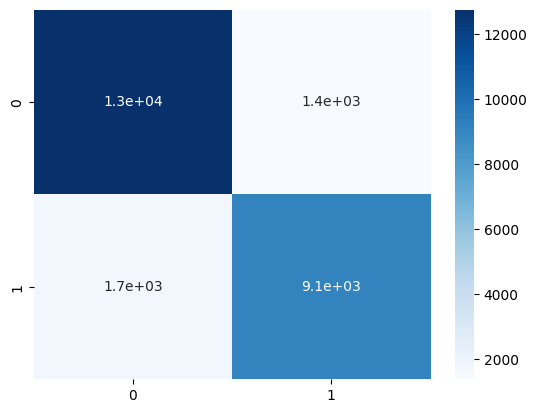

In [37]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Blues')
print(classification_report(y_test, y_pred)) 


Treniranje 70:30

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [39]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 0, 0], shape=(37500,))

[[19194  2052]
 [ 2622 13632]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     21246
           1       0.87      0.84      0.85     16254

    accuracy                           0.88     37500
   macro avg       0.87      0.87      0.87     37500
weighted avg       0.88      0.88      0.88     37500



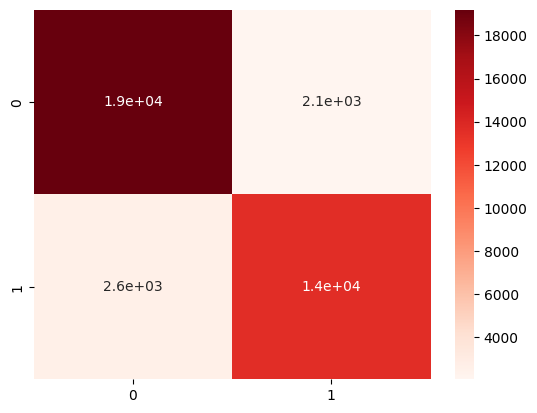

In [42]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Reds')
print(classification_report(y_test, y_pred)) 

Treniranje 90:10

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state = 0)

In [44]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [45]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [46]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 1, 1], shape=(12500,))

[[6343  705]
 [ 870 4582]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      7048
           1       0.87      0.84      0.85      5452

    accuracy                           0.87     12500
   macro avg       0.87      0.87      0.87     12500
weighted avg       0.87      0.87      0.87     12500



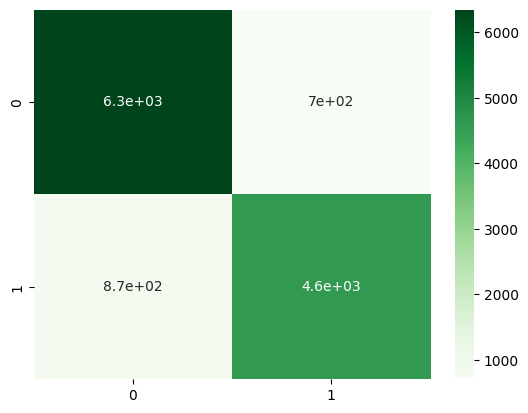

In [47]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Greens')
print(classification_report(y_test, y_pred)) 

Treniranje na drugoj skupini varijabli

In [48]:
feature_sets = {
    'Osnovne_demografske': ['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class'],
    
    'Varijable_leta': ['Flight Distance', 'Departure Delay', 'Arrival Delay', 
                       'Departure and Arrival Time Convenience'],
    
    'Varijable_usluga': ['Check-in Service', 'Online Boarding', 'Gate Location', 
                         'On-board Service', 'Seat Comfort', 'Leg Room Service', 
                         'Cleanliness', 'Food and Drink', 'In-flight Service', 
                         'In-flight Wifi Service', 'In-flight Entertainment', 
                         'Baggage Handling'],
    
    'Kombinovane_kljucne': ['Age', 'Customer Type', 'Type of Travel', 'Class', 
                            'Flight Distance', 'Online Boarding', 'Seat Comfort', 
                            'Cleanliness', 'In-flight Entertainment']
}

train_test_ratios = [0.2,0.3,0.1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluacija modela i vraćanje metrika"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    
    return metrics

In [49]:
results_logreg = []

for tt_ratio in train_test_ratios:
    print(f"\n--- T/T omjer: test_size = {tt_ratio} ---")
    
    for feature_set_name, features in feature_sets.items():
        # Priprema podataka za ovaj set varijabli
        X_selected = df[features]
        y_target = df['Satisfaction']
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_selected, y_target, test_size=tt_ratio, random_state=42
        )
        
        # Standardizacija
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Treniranje Logističke regresije
        logreg = LogisticRegression(max_iter=1000, random_state=42)
        logreg.fit(X_train_scaled, y_train)
        
        # Evaluacija
        metrics = evaluate_model(logreg, X_test_scaled, y_test, 'LogisticRegression')
        metrics['test_size'] = tt_ratio
        metrics['feature_set'] = feature_set_name
        metrics['n_features'] = len(features)
        
        results_logreg.append(metrics)
        
        print(f"  {feature_set_name:25s} | Acc: {metrics['accuracy']:.4f} | "
              f"F1: {metrics['f1_score']:.4f} | Prec: {metrics['precision']:.4f}")


--- T/T omjer: test_size = 0.2 ---
  Osnovne_demografske       | Acc: 0.7808 | F1: 0.7409 | Prec: 0.7542
  Varijable_leta            | Acc: 0.6642 | F1: 0.5253 | Prec: 0.6711
  Varijable_usluga          | Acc: 0.8108 | F1: 0.7766 | Prec: 0.7898
  Kombinovane_kljucne       | Acc: 0.8483 | F1: 0.8221 | Prec: 0.8299

--- T/T omjer: test_size = 0.3 ---
  Osnovne_demografske       | Acc: 0.7809 | F1: 0.7424 | Prec: 0.7561
  Varijable_leta            | Acc: 0.6629 | F1: 0.5240 | Prec: 0.6740
  Varijable_usluga          | Acc: 0.8099 | F1: 0.7769 | Prec: 0.7896
  Kombinovane_kljucne       | Acc: 0.8478 | F1: 0.8222 | Prec: 0.8320

--- T/T omjer: test_size = 0.1 ---
  Osnovne_demografske       | Acc: 0.7825 | F1: 0.7449 | Prec: 0.7597
  Varijable_leta            | Acc: 0.6609 | F1: 0.5209 | Prec: 0.6749
  Varijable_usluga          | Acc: 0.8112 | F1: 0.7782 | Prec: 0.7951
  Kombinovane_kljucne       | Acc: 0.8474 | F1: 0.8222 | Prec: 0.8333


In [51]:
results_df_logreg = pd.DataFrame(results_logreg)

# Sortiranje po F1 score i accuracy
best_logreg = results_df_logreg.sort_values(['f1_score', 'accuracy'], ascending=False).iloc[0]

print("\n" + "=" * 80)
print("NAJBOLJA KOMBINACIJA ZA LOGISTIČKU REGRESIJU:")
print("=" * 80)
print(f"  Feature set      : {best_logreg['feature_set']}")
print(f"  Test size        : {best_logreg['test_size']}")
print(f"  Broj varijabli   : {int(best_logreg['n_features'])}")
print(f"  Accuracy         : {best_logreg['accuracy']:.4f}")
print(f"  F1-score         : {best_logreg['f1_score']:.4f}")
print(f"  Precision        : {best_logreg['precision']:.4f}")
print(f"  Recall           : {best_logreg['recall']:.4f}")


NAJBOLJA KOMBINACIJA ZA LOGISTIČKU REGRESIJU:
  Feature set      : Kombinovane_kljucne
  Test size        : 0.3
  Broj varijabli   : 9
  Accuracy         : 0.8478
  F1-score         : 0.8222
  Precision        : 0.8320
  Recall           : 0.8126


2. algoritam - Decision Tree

In [52]:
from sklearn.tree import DecisionTreeClassifier

# Koristi se najbolji feature set i T/T omjer iz Logističke regresije
best_features = feature_sets[best_logreg['feature_set']]
best_test_size = best_logreg['test_size']

print(f"\nKoristi se:")
print(f"  Feature set      : {best_logreg['feature_set']}")
print(f"  Varijable        : {best_features}")
print(f"  Test size        : {best_test_size}")

# Priprema podataka sa najboljom kombinacijom
X_best = df[best_features]
y_target = df['Satisfaction']

# Train-test split sa istim random_state radi reproduktivnosti
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y_target, test_size=best_test_size, random_state=42
)

# Standardizacija
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treniranje Decision Tree modela
# Tuning osnovnih parametara za bolje performanse
dt_params = {
    'max_depth': 10,
    'min_samples_split': 50,
    'min_samples_leaf': 25,
    'criterion': 'gini',
    'random_state': 42
}

decision_tree = DecisionTreeClassifier(**dt_params)
decision_tree.fit(X_train_scaled, y_train)

# Evaluacija Decision Tree modela
dt_metrics = evaluate_model(decision_tree, X_test_scaled, y_test, 'DecisionTree')

print(f"\nREZULTATI DECISION TREE:")
print(f"  Accuracy  : {dt_metrics['accuracy']:.4f}")
print(f"  Precision : {dt_metrics['precision']:.4f}")
print(f"  Recall    : {dt_metrics['recall']:.4f}")
print(f"  F1-score  : {dt_metrics['f1_score']:.4f}")


Koristi se:
  Feature set      : Kombinovane_kljucne
  Varijable        : ['Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Online Boarding', 'Seat Comfort', 'Cleanliness', 'In-flight Entertainment']
  Test size        : 0.3

REZULTATI DECISION TREE:
  Accuracy  : 0.9111
  Precision : 0.9261
  Recall    : 0.8636
  F1-score  : 0.8938
